In [1]:
import os
import glob
import re
import h5py
import numpy as np
import pandas as pd
import random
from typing import Tuple, Literal, Optional, List, Union, Dict
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.signal import decimate
from scipy.stats import mode
from statistics import mode as stat_mode
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import itertools
# For CNN/RNN
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, InputLayer
)
from tensorflow.keras.optimizers import Adam


# Loading files

In [2]:
_CHUNK_RE = re.compile(r'_(\d+)\.h5$')      

def _get_dataset_name(path: str) -> str:
    """Return the internal dataset name inside the HDF5 file."""
    return "_".join(os.path.basename(path).split('_')[:-1])

def load_participant_arrays(participant_id: int, base_dir: str = "\train"):
    """
    Concatenate all chunks for every task of one participant and return
    four NumPy arrays in the order:
        rest, task_motor, task_story_math, task_working_memory

    Each array has shape (n_nodes, total_timepoints) or is None.
    """
    # buckets: task → list[(chunk_number, matrix)]
    buckets = {
        "rest":               [],
        "task_motor":         [],
        "task_story_math":    [],
        "task_working_memory": []
    }

    # find all relevant files, e.g. rest_105923_1.h5
    pattern = os.path.join(base_dir, f"*_{participant_id}_*.h5")
    for path in glob.glob(pattern):
        ds_name = _get_dataset_name(path)

        # identify task & chunk number
        task = next((t for t in buckets if ds_name.startswith(t)), None)
        if task is None:
            continue  # skip unrecognised file

        chunk_match = _CHUNK_RE.search(path)
        chunk_num = int(chunk_match.group(1)) if chunk_match else 0

        # load matrix
        with h5py.File(path, "r") as f:
            matrix = f[ds_name][()]        # (nodes, timepoints)

        buckets[task].append((chunk_num, matrix))

    # concatenate chunks for each task
    out = []
    for task, lst in buckets.items():
        if not lst:
            out.append(None)
            continue

        # sort by chunk number to keep temporal order
        lst.sort(key=lambda item: item[0])
        matrices = [m for _, m in lst]

        # sanity‑check dimensionality: all chunks must share the node axis size
        first_rows = matrices[0].shape[0]
        if not all(mat.shape[0] == first_rows for mat in matrices):
            raise ValueError(f"Inconsistent node counts in {task} chunks for participant {participant_id}")

        # concat along time axis (axis=1)
        out.append(np.concatenate(matrices, axis=1))

    return tuple(out)  # (rest, motor, story_math, working_memory)


## Intra files

### Intra Training Files

In [3]:
## TRAINING DATA ##
## This can only be loaded locally now, maybe we need to change it before we hand it in?

# intra 1
participant_id_intra = 105923
rest_intra, motor_intra, story_math_intra, wm_intra = load_participant_arrays(participant_id_intra, base_dir=r"C:\Users\odiee\OneDrive\Documents\24-25\Blok4\Deep Learning\Assignments\Assignment 2\Final Project data\Intra\train")


print("Rest:", None if rest_intra is None else rest_intra.shape)
print("Motor:", None if motor_intra is None else motor_intra.shape)
print("Story/Math:", None if story_math_intra is None else story_math_intra.shape)
print("Working Memory:", None if wm_intra is None else wm_intra.shape)


Rest: (248, 284992)
Motor: (248, 284992)
Story/Math: (248, 284992)
Working Memory: (248, 284992)


### Intra Testing Files

In [4]:
## TEST DATA ##
rest_intra_test, motor_intra_test, story_math_intra_test, wm_intra_test = load_participant_arrays(participant_id_intra, base_dir=r"C:\Users\odiee\OneDrive\Documents\24-25\Blok4\Deep Learning\Assignments\Assignment 2\Final Project data\Intra\test")
print("Rest:", None if rest_intra is None else rest_intra_test.shape)
print("Motor:", None if motor_intra is None else motor_intra_test.shape)
print("Story/Math:", None if story_math_intra is None else story_math_intra_test.shape)
print("Working Memory:", None if wm_intra is None else wm_intra_test.shape)


Rest: (248, 71248)
Motor: (248, 71248)
Story/Math: (248, 71248)
Working Memory: (248, 71248)


## Contra Files

### Contra Training files

In [3]:
## TRAINING DATA ##

# contra 1
participant_id_c1 = 113922

#contra 2
participant_id_c2 = 164636


rest_c1, motor_c1, story_math_c1, wm_c1 = load_participant_arrays(participant_id_c1, base_dir=r"C:\Users\odiee\OneDrive\Documents\24-25\Blok4\Deep Learning\Assignments\Assignment 2\Final Project data\Cross\train")
rest_c2, motor_c2, story_math_c2, wm_c2 = load_participant_arrays(participant_id_c2, base_dir=r"C:\Users\odiee\OneDrive\Documents\24-25\Blok4\Deep Learning\Assignments\Assignment 2\Final Project data\Cross\train")

print("Rest:", None if rest_c2 is None else rest_c2.shape)
print("Motor:", None if motor_c2 is None else motor_c2.shape)
print("Story/Math:", None if story_math_c2 is None else story_math_c2.shape)
print("Working Memory:", None if wm_c2 is None else wm_c2.shape)

Rest: (248, 284992)
Motor: (248, 284992)
Story/Math: (248, 284992)
Working Memory: (248, 284992)



### Contra Testing Files

In [23]:
## TESTING DATA ##

participant_id_cross1= 162935
participant_id_cross2= 707749
participant_id_cross3= 725751
participant_id_cross4 = 735148
rest_cross1, motor_cross1, story_math_cross1, wm_cross1 = load_participant_arrays(participant_id_cross1, base_dir=r"C:\Users\odiee\OneDrive\Documents\24-25\Blok4\Deep Learning\Assignments\Assignment 2\Final Project data\Cross\test1")
rest_cross2, motor_cross2, story_math_cross2, wm_cross2 = load_participant_arrays(participant_id_cross2, base_dir=r"C:\Users\odiee\OneDrive\Documents\24-25\Blok4\Deep Learning\Assignments\Assignment 2\Final Project data\Cross\test2")
rest_cross3, motor_cross3, story_math_cross3, wm_cross3 = load_participant_arrays(participant_id_cross3, base_dir=r"C:\Users\odiee\OneDrive\Documents\24-25\Blok4\Deep Learning\Assignments\Assignment 2\Final Project data\Cross\test3")
rest_cross4, motor_cross4, story_math_cross4, wm_cross4 = load_participant_arrays(participant_id_cross4, base_dir=r"C:\Users\odiee\OneDrive\Documents\24-25\Blok4\Deep Learning\Assignments\Assignment 2\Final Project data\Cross\test3")


print("Rest:", None if rest_cross3 is None else rest_cross3.shape)
print("Motor:", None if motor_cross3 is None else motor_cross3.shape)
print("Story/Math:", None if story_math_cross3 is None else story_math_cross3.shape)
print("Working Memory:", None if wm_cross3 is None else wm_cross3.shape)

Rest: (248, 71248)
Motor: (248, 71248)
Story/Math: (248, 71248)
Working Memory: (248, 71248)


In [24]:
test_datasets1 = [rest_cross1, motor_cross1, story_math_cross1, wm_cross1]
test_datasets2 = [rest_cross2, motor_cross2, story_math_cross2, wm_cross2]
test_datasets3 = [rest_cross3, motor_cross3, story_math_cross3, wm_cross3]
test_datasets4 = [rest_cross4, motor_cross4, story_math_cross4, wm_cross4]

# Pre-Processing Functions

### Apply normalization and downsampling on test set given normalization/downsampling dictionary

In [5]:
def apply_norm_ds_test(
    arr: np.ndarray,
    *,
    params: dict,
    axis: int = 1,
    eps: float = 1e-12
) -> np.ndarray:
    """
    Apply normalization and downsampling using precomputed parameters.

    Parameters:
        arr: 2D MEG array [sensors x time]
        params: Dict containing keys:
            - 'scaling': "zscore" or "minmax"
            - and one of:
                - 'mean' and 'std' (for zscore)
                - 'min' and 'max' (for minmax)
            - Optional downsampling:
                - 'downsample_method': "slice" or "decimate"
                - 'downsample_factor': int > 1
        axis: Axis along which to apply normalization and downsampling
        eps: Stability term

    Returns:
        Processed array
    """
    # --- Normalization ---
    scaling = params.get("scaling")
    if scaling == "zscore":
        mean = params["mean"]
        std = params["std"]
        arr = (arr - mean) / (std + eps)
    elif scaling == "minmax":
        min_ = params["min"]
        max_ = params["max"]
        arr = (arr - min_) / (max_ - min_ + eps)
    else:
        raise ValueError("Invalid or missing 'scaling' key in params")

    downsample_factor = params.get("downsample_factor", 1)
    downsample_method = params.get("downsample_method", "decimate")

    if downsample_factor > 1:
        if downsample_method == "slice":
            slicer = [slice(None)] * arr.ndim
            slicer[axis] = slice(None, None, downsample_factor)
            arr = arr[tuple(slicer)]
        elif downsample_method == "decimate":
            arr = decimate(arr, downsample_factor, axis=axis, zero_phase=True)
        else:
            raise ValueError("Invalid 'downsample_method' in params")

    return arr

## Intra: downsampling and normalization

In [4]:
def preprocess_meg_data(
    arr: np.ndarray,
    *,
    scaling: Literal["zscore", "minmax"] = "zscore",
    axis: int = 1,  # time axis
    downsample_method: Literal["slice", "decimate"] = "decimate",
    downsample_factor: Optional[int] = None,
    target_rate: Optional[int] = None,
    orig_rate: int = 2034,
    eps: float = 1e-12,
    scaling_params: Optional[Dict[str, np.ndarray]] = None,
    return_params: bool = False
) -> Union[np.ndarray, Tuple[np.ndarray, Dict[str, np.ndarray]]]:

    if scaling == "zscore":
        if scaling_params is None:
            means = arr.mean(axis=axis, keepdims=True)
            stds = arr.std(axis=axis, keepdims=True)
        else:
            means = scaling_params["mean"]
            stds = scaling_params["std"]
        arr = (arr - means) / (stds + eps)
        current_params = {"mean": means, "std": stds}

    elif scaling == "minmax":
        if scaling_params is None:
            mins = arr.min(axis=axis, keepdims=True)
            maxs = arr.max(axis=axis, keepdims=True)
        else:
            mins = scaling_params["min"]
            maxs = scaling_params["max"]
        arr = (arr - mins) / (maxs - mins + eps)
        current_params = {"min": mins, "max": maxs}

    else:
        raise ValueError("scaling must be 'zscore' or 'minmax'")

    # Determine downsampling factor
    if downsample_factor is None:
        if target_rate is None:
            raise ValueError("Specify either downsample_factor or target_rate")
        downsample_factor = int(round(orig_rate / target_rate))

    # Downsampling
    if downsample_factor > 1:
        if downsample_method == "slice":
            slicer = [slice(None)] * arr.ndim
            slicer[axis] = slice(None, None, downsample_factor)
            arr = arr[tuple(slicer)]
        elif downsample_method == "decimate":
            arr = decimate(arr, downsample_factor, axis=axis, zero_phase=True)
        else:
            raise ValueError("downsample_method must be 'slice' or 'decimate'")

    return (arr, current_params) if return_params else arr


## Clustering functions

In [6]:
def cossim_cluster_multi_task(task_list, n_clusters=5):
    """
    output:
        sorted_indices: Indices that reorder sensors by cluster.
        labels: Cluster labels for each sensor.
        avg_sim_matrix: Averaged cosine similarity matrix.
    """

    # cosine similarity matrix for each task
    sim_matrices = []
    for task in task_list:
        sim = cosine_similarity(task)
        sim_matrices.append(sim)

    # avg similarity matrices
    avg_sim_matrix = np.mean(sim_matrices, axis=0)
    avg_dist_matrix = 1 - avg_sim_matrix

    # clustering
    clustering = AgglomerativeClustering(
        metric='precomputed',
        linkage='average',
        n_clusters=n_clusters
    )
    labels = clustering.fit_predict(avg_dist_matrix)

    # reorder indices
    sorted_indices = np.argsort(labels)

    return sorted_indices, labels, avg_sim_matrix


In [7]:
def combine_cluster_order(labels1, labels2, threshold=2, n_clusters=5):
    n_sensors = len(labels1)
    combined_labels = -1 * np.ones(n_sensors, dtype=int)
    ordered_indices = []

    for cluster_id in range(n_clusters):
        mask1 = labels1 == cluster_id
        mask2 = labels2 == cluster_id

        if threshold == 1:  # union
            combined_mask = mask1 | mask2
        elif threshold == 2:  # intersection
            combined_mask = mask1 & mask2
        else:
            raise ValueError("Threshold must be 1 (union) or 2 (intersection)")

        indices = np.where(combined_mask)[0]
        #print("Indices: ", len(indices))
        combined_labels[indices] = cluster_id
        ordered_indices.extend(indices.tolist())
        

    # Remove duplicates while preserving order
    seen = set()
    ordered_indices = [x for x in ordered_indices if not (x in seen or seen.add(x))]
    print("\n Ordered indices: ", len(ordered_indices))
    return np.array(ordered_indices), combined_labels


# Pre-processing Training data

## Training Intra

In [ ]:
datasets = [rest_intra, motor_intra, story_math_intra, wm_intra]
task_names = ["rest", "motor", "story_math", "wm"]

# preprocessing all datasets
preprocessed_datasets = [
    preprocess_meg_data(
        data,
        scaling="zscore",
        downsample_method="decimate",
        target_rate=64,
        orig_rate=2034
    )
    for data in datasets
]

processed_data_list, norm_params_intra = zip(*preprocessed_datasets)


# clustering using averaged cosine similarity
sensor_order_intra, cluster_labels, avg_sim_matrix = cossim_cluster_multi_task(
    preprocessed_datasets,
    n_clusters=5
)

# reorder and store data per task
reordered_data_dict = {}
sensor_order_dict = {}
cluster_labels_dict = {}

for preproc_data, name in zip(preprocessed_datasets, task_names):
    reordered_data = preproc_data[sensor_order_intra, :]
    reordered_data_dict[f"reordered_data_{name}"] = reordered_data
    sensor_order_dict[f"sensor_order_{name}"] = sensor_order_intra
    cluster_labels_dict[f"cluster_labels_{name}"] = cluster_labels


In [16]:
intra_vars = {}

for cond in ["rest", "motor", "story_math", "wm"]:
    intra_vars[cond] = {
        "data": reordered_data_dict[f"reordered_data_{cond}"],
        "sensor_order": sensor_order_dict[f"sensor_order_{cond}"],
        "clusters": cluster_labels_dict[f"cluster_labels_{cond}"]
    }

# Simple FFN

## Global FFN functions

In [17]:
def extract_snapshots(data, time_per_snapshot=32, agg_func=np.mean, method='time'):
    """
    Extract 1s snapshots with time or space aggregation.
    """
    sensors, total_time = data.shape
    snapshots = []
    for start in range(0, total_time - time_per_snapshot + 1, time_per_snapshot):
        snap = data[:, start:start + time_per_snapshot]
        if method == 'time':
            agg = agg_func(snap, axis=1)
        else:
            agg = agg_func(snap, axis=0)
        snapshots.append(agg)
    return np.stack(snapshots)

In [18]:
label_map = {
    "rest": 0,
    "motor": 1,
    "story_math": 2,
    "wm": 3
}

In [21]:

# Build FFNN model
def build_ffnn(input_shape, dense_units=128, dropout_rate=0.3, num_classes=4):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(dense_units // 2, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [23]:
def plot_training_history(history, metrics=['loss', 'accuracy']):
    """
    Plot training and validation metrics from Keras history.

    Parameters:
        history: Keras History object (e.g., returned by model.fit)
        metrics: List of metrics to plot (default: ['loss', 'accuracy'])
    """
    if not hasattr(history, 'history'):
        raise ValueError("Expected a Keras History object")

    history_dict = history.history
    epochs = range(1, len(history_dict[metrics[0]]) + 1)

    for metric in metrics:
        plt.figure(figsize=(8, 4))
        plt.plot(epochs, history_dict[metric], 'b-', label=f'Train {metric}')
        val_metric = f'val_{metric}'
        if val_metric in history_dict:
            plt.plot(epochs, history_dict[val_metric], 'r--', label=f'Val {metric}')
        plt.title(f'{metric.capitalize()} over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel(metric.capitalize())
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [25]:
from scipy.stats import mode

def predict_full_sequence(model, data, method = 'space', time_per_snapshot=32, agg='mean'):
    snapshots = extract_snapshots(data, method = method, time_per_snapshot = time_per_snapshot)
    probs = model.predict(snapshots)

    if agg == 'mean':
        return int(np.argmax(np.mean(probs, axis=0)))
    elif agg == 'vote':
        preds = np.argmax(probs, axis=1)
        return int(mode(preds).mode[0])

## Intra FFN

### Time aggregation

In [20]:
# Prepare snapshot-level dataset
X_rest = extract_snapshots(intra_vars["rest"]["data"], method='time')
X_motor = extract_snapshots(intra_vars["motor"]["data"], method='time')
X_story = extract_snapshots(intra_vars["story_math"]["data"], method='time')
X_wm = extract_snapshots(intra_vars["wm"]["data"], method='time')

y_rest = np.full((X_rest.shape[0],), label_map['rest'])
y_motor = np.full((X_motor.shape[0],), label_map['motor'])
y_story = np.full((X_story.shape[0],), label_map['story_math'])
y_wm = np.full((X_wm.shape[0],), label_map['wm'])

X_all = np.concatenate([X_rest, X_motor, X_story, X_wm])
y_all = np.concatenate([y_rest, y_motor, y_story, y_wm])


# shuffle??
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)

In [22]:
# Instantiate and compile
snapshot_model_time = build_ffnn(input_shape=(X_train.shape[1],))

snapshot_model_time.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
snapshot_history_time = snapshot_model_time.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    verbose=1
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4765 - loss: 1.2172 - val_accuracy: 0.9283 - val_loss: 0.4425
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8698 - loss: 0.4748 - val_accuracy: 0.9821 - val_loss: 0.1654
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9425 - loss: 0.2446 - val_accuracy: 0.9955 - val_loss: 0.0745
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9861 - loss: 0.1341 - val_accuracy: 0.9955 - val_loss: 0.0361
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9874 - loss: 0.1043 - val_accuracy: 1.0000 - val_loss: 0.0213
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9829 - loss: 0.0712 - val_accuracy: 1.0000 - val_loss: 0.0139
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9802 - loss: 0.0587 - val_accuracy: 1.0000 - val_loss: 0.0114
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9920 - loss: 0.0468 - val_accuracy: 1.0000 - val_loss:

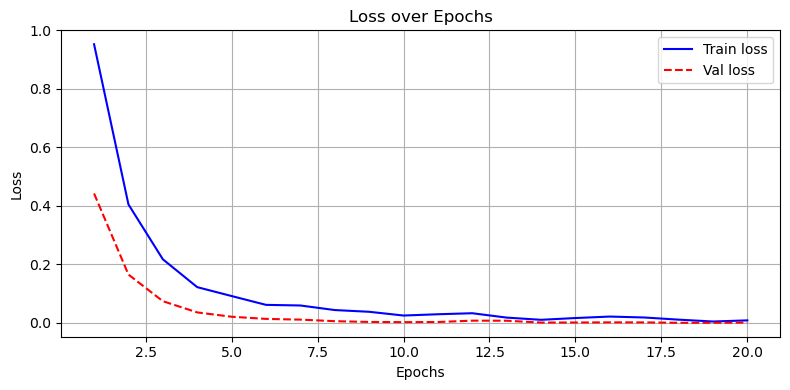

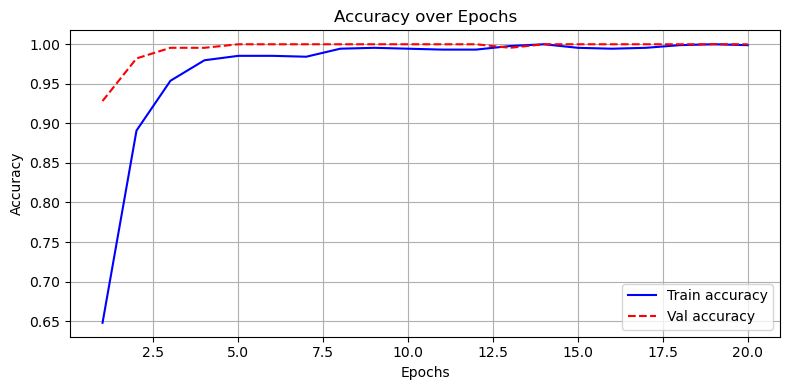

In [24]:
plot_training_history(snapshot_history_time, metrics=['loss', 'accuracy'])

In [27]:
X_sequences = [intra_vars["rest"]["data"], intra_vars["motor"]["data"], intra_vars["story_math"]["data"], intra_vars["wm"]["data"]]
y_true = [0, 1, 2, 3]  # true labels corresponding to above


y_pred = [predict_full_sequence(snapshot_model_time, seq, method = 'time') for seq in X_sequences]
print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=label_map.keys()))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("Snapshot validation accuracy:", snapshot_model_time.evaluate(X_val, y_val)[1])
print("Sequence aggregated accuracy:", accuracy_score(y_true, y_pred))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

        rest       1.00      1.00      1.00         1
       motor       1.00      1.00      1.00         1
  story_math       1.00      1.00      1.00         1
          wm       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


Confusion Matrix:
 [[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0028 
Snapshot validation accuracy: 1.0
Sequence aggregated accuracy: 1.0


### Space Aggregation

In [28]:
# Prepare snapshot-level dataset
X_rest = extract_snapshots(intra_vars["rest"]["data"], method='space')
X_motor = extract_snapshots(intra_vars["motor"]["data"], method='space')
X_story = extract_snapshots(intra_vars["story_math"]["data"], method='space')
X_wm = extract_snapshots(intra_vars["wm"]["data"], method='space')

y_rest = np.full((X_rest.shape[0],), label_map['rest'])
y_motor = np.full((X_motor.shape[0],), label_map['motor'])
y_story = np.full((X_story.shape[0],), label_map['story_math'])
y_wm = np.full((X_wm.shape[0],), label_map['wm'])

X_all = np.concatenate([X_rest, X_motor, X_story, X_wm])
y_all = np.concatenate([y_rest, y_motor, y_story, y_wm])


# shuffle??
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)

In [29]:
snapshot_model_space = build_ffnn(input_shape=(X_train.shape[1],))

snapshot_model_space.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
snapshot_history_space = snapshot_model_space.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    verbose=1
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2640 - loss: 1.3895 - val_accuracy: 0.2870 - val_loss: 1.3786
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2644 - loss: 1.3820 - val_accuracy: 0.3587 - val_loss: 1.3661
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3427 - loss: 1.3556 - val_accuracy: 0.4081 - val_loss: 1.3502
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3585 - loss: 1.3479 - val_accuracy: 0.3767 - val_loss: 1.3419
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3405 - loss: 1.3514 - val_accuracy: 0.4215 - val_loss: 1.3312
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3658 - loss: 1.3359 - val_accuracy: 0.4170 - val_loss: 1.3170
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3586 - loss: 1.3262 - val_accuracy: 0.3812 - val_loss: 1.3046
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3734 - loss: 1.3258 - val_accuracy: 0.4619 - val_loss:

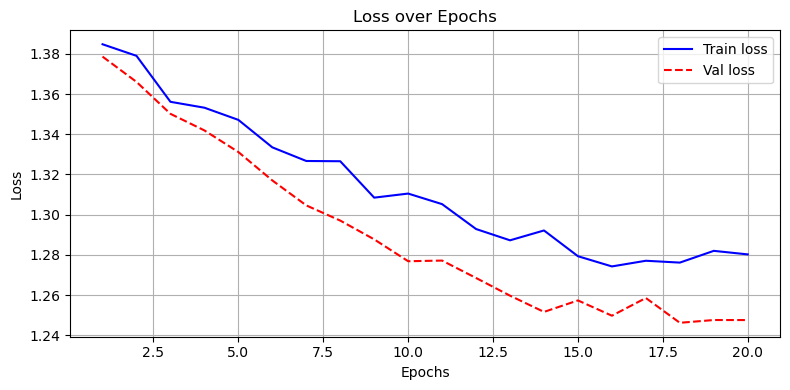

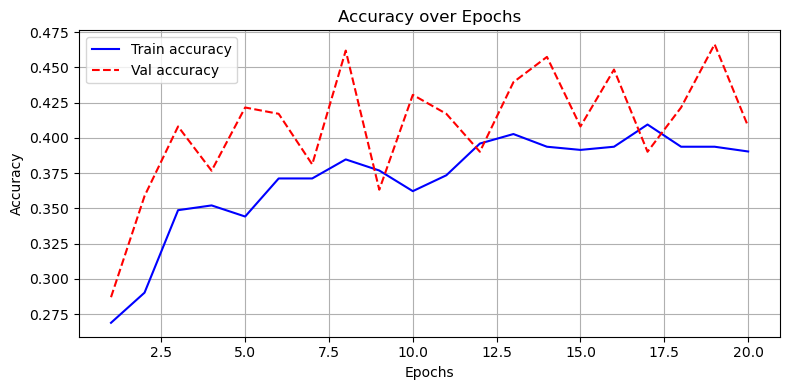

In [30]:
plot_training_history(snapshot_history_space, metrics=['loss', 'accuracy'])

In [34]:
X_sequences = [intra_vars["rest"]["data"], intra_vars["motor"]["data"], intra_vars["story_math"]["data"], intra_vars["wm"]["data"]]
y_true = [0, 1, 2, 3]  # true labels corresponding to above


y_pred = [predict_full_sequence(snapshot_model_space, seq) for seq in X_sequences]
print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=label_map.keys(), zero_division=0))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("Snapshot validation accuracy:", snapshot_model_space.evaluate(X_val, y_val)[1])
print("Sequence aggregated accuracy:", accuracy_score(y_true, y_pred))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Accuracy: 0.75

Classification Report:
               precision    recall  f1-score   support

        rest       0.00      0.00      0.00         1
       motor       1.00      1.00      1.00         1
  story_math       0.50      1.00      0.67         1
          wm       1.00      1.00      1.00         1

    accuracy                           0.75         4
   macro avg       0.62      0.75      0.67         4
weighted avg       0.62      0.75      0.67         4


Confusion Matrix:
 [[0 0 1 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4092 - loss: 1.2533 
Snapshot validation accuracy: 0.40807175636291504
Sequence aggregated accuracy: 0.75


## Testing Intra FFN

In [ ]:
datasets_test_intra = [rest_intra_test, motor_intra_test, story_math_intra_test, wm_intra_test]

testdata_intra = [
    apply_norm_ds_test(data, params=params)
    for data, params in zip(datasets_test_intra, norm_params_intra)
]

for preproc_data, name in zip(testdata_intra, task_names):
    reordered_data = preproc_data[sensor_order_intra, :]
    reordered_data_dict[f"reordered_data_{name}"] = reordered_data
    sensor_order_dict[f"sensor_order_{name}"] = sensor_order_intra
    cluster_labels_dict[f"cluster_labels_{name}"] = cluster_labels

In [ ]:
intra_vars_test = {}

for cond in ["rest", "motor", "story_math", "wm"]:
    intra_vars_test[cond] = {
        "data": reordered_data_dict[f"reordered_data_{cond}"],
        "sensor_order": sensor_order_dict[f"sensor_order_{cond}"],
        "clusters": cluster_labels_dict[f"cluster_labels_{cond}"]
    }

### Space & Time aggregation

In [ ]:
snapshot_results = {}
sequence_results = {}

model_map = {
    "time": snapshot_model_time,
    "space": snapshot_model_space,
}

for method in ["time", "space"]:
    model = model_map[method]
    snapshot_results[method] = {}
    sequence_results[method] = {}

    X_all = []
    y_all = []
    X_sequences = []
    y_true = []

    for condition, label in label_map.items():
        # Get data for this condition
        data = intra_vars_test[condition]["data"]

        # Snapshot-level prep
        X = extract_snapshots(data, method=method)
        y = np.full((X.shape[0],), label)

        X_all.append(X)
        y_all.append(y)

        # Sequence-level prep
        X_sequences.append(data)
        y_true.append(label)

    # Concatenate snapshot-level inputs
    X_all = np.concatenate(X_all)
    y_all = np.concatenate(y_all)

    # Snapshot-level evaluation
    snapshot_acc = model.evaluate(X_all, y_all, verbose=0)[1]
    snapshot_results[method]["single_test"] = snapshot_acc

    # Sequence-level predictions
    y_pred = [predict_full_sequence(model, seq, method=method) for seq in X_sequences]
    sequence_acc = accuracy_score(y_true, y_pred)
    sequence_results[method]["single_test"] = {
        "accuracy": sequence_acc,
        "report": classification_report(y_true, y_pred, target_names=label_map.keys(), output_dict=False, zero_division=0),
        "confusion": confusion_matrix(y_true, y_pred)
    }

    # Optional: print results
    print(f"\n=== INTRA TEST ({method.upper()}) ===")
    print("Sequence Accuracy:", sequence_acc)
    print("Snapshot Accuracy:", snapshot_acc)
    print("Classification Report:\n", classification_report(y_true, y_pred, target_names=label_map.keys(), zero_division=0))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))


## Contra: Downsampling & normalization

In [8]:
### Contra
def preprocess_and_split_meg_data(
    arr: np.ndarray,
    *,  # keyword-only arguments
    scaling: Literal["zscore", "minmax"] = "zscore",
    axis: int = 1,
    downsample_method: Literal["slice", "decimate"] = "decimate",
    downsample_factor: Optional[int] = None,
    target_rate: Optional[int] = None,
    orig_rate: int = 2034,
    eps: float = 1e-12,
    return_params: bool = False
) -> Union[Tuple[np.ndarray, np.ndarray], Tuple[np.ndarray, np.ndarray, dict]]:
    """
    Normalize entire MEG array, split midway along time, and downsample each half.

    Parameters:
        arr: 2D MEG array [sensors x time] (concatenated)
        scaling: "zscore" or "minmax"
        axis: Axis along which to scale/split/downsample (default: time)
        downsample_method: "slice" or "decimate"
        downsample_factor: Optional integer downsampling factor
        target_rate: Optional new sample rate (alternative to factor)
        orig_rate: Original sample rate (used with target_rate)
        eps: Stability term
        return_params: If True, also return the normalization parameters

    Returns:
        Tuple of two preprocessed MEG arrays [sensors x reduced_time]
        Optionally, a dict of normalization parameters
    """
    params = {}

    # Normalize entire array
    if scaling == "zscore":
        means = arr.mean(axis=axis, keepdims=True)
        stds = arr.std(axis=axis, keepdims=True)
        arr = (arr - means) / (stds + eps)
        if return_params:
            params["scaling"] = "zscore"
            params["mean"] = means
            params["std"] = stds
    elif scaling == "minmax":
        mins = arr.min(axis=axis, keepdims=True)
        maxs = arr.max(axis=axis, keepdims=True)
        arr = (arr - mins) / (maxs - mins + eps)
        if return_params:
            params["scaling"] = "minmax"
            params["min"] = mins
            params["max"] = maxs
    else:
        raise ValueError("scaling must be 'zscore' or 'minmax'")

    # Split in half
    time_len = arr.shape[axis]
    mid = time_len // 2

    slicer1 = [slice(None)] * arr.ndim
    slicer2 = [slice(None)] * arr.ndim
    slicer1[axis] = slice(0, mid)
    slicer2[axis] = slice(mid, None)

    arr1 = arr[tuple(slicer1)]
    arr2 = arr[tuple(slicer2)]

    # Determine downsampling factor
    if downsample_factor is None:
        if target_rate is None:
            raise ValueError("Specify either downsample_factor or target_rate")
        downsample_factor = int(round(orig_rate / target_rate))

    # Downsample each half
    if downsample_factor > 1:
        if downsample_method == "slice":
            slicer = [slice(None)] * arr.ndim
            slicer[axis] = slice(None, None, downsample_factor)
            arr1 = arr1[tuple(slicer)]
            arr2 = arr2[tuple(slicer)]
        elif downsample_method == "decimate":
            arr1 = decimate(arr1, downsample_factor, axis=axis, zero_phase=True)
            arr2 = decimate(arr2, downsample_factor, axis=axis, zero_phase=True)
        else:
            raise ValueError("downsample_method must be 'slice' or 'decimate'")

    if return_params:
        params["downsample_factor"] = downsample_factor
        params["downsample_method"] = downsample_method
        return arr1, arr2, params

    return arr1, arr2


In [9]:
datasets_c1 = [rest_c1, motor_c1, story_math_c1, wm_c1]
datasets_c2 = [rest_c2, motor_c2, story_math_c2, wm_c2]
datasets_contra = [np.concatenate((d1, d2), axis=1) for d1, d2 in zip(datasets_c1, datasets_c2)]
task_names = ["rest", "motor", "story_math", "wm"]

In [10]:
# preprocessing all datasets
split_datasets_contra_with_params = [
    preprocess_and_split_meg_data(
        data,
        scaling="zscore",
        downsample_method="decimate",
        target_rate=64,
        orig_rate=2034,
        return_params=True
    )
    for data in datasets_contra
]

# unpack separately
split1_contra, split2_contra, norm_params_contra = zip(*split_datasets_contra_with_params)

In [ ]:
reordered_data_dict_contra = {}
sensor_order_dict_contra = {}
cluster_labels_dict_contra = {}

# Cluster across all 4 tasks per participant
_, labels1, _ = cossim_cluster_multi_task(split1_contra)  # list of 4 datasets
_, labels2, _ = cossim_cluster_multi_task(split2_contra)

# Get sensor order and cluster labels
sensor_order_contra, cluster_labels = combine_cluster_order(
    labels1,
    labels2,
    threshold=1,
    n_clusters=5
)

# Reorder all datasets individually
for data1, data2, name in zip(split1_contra, split2_contra, task_names):
    reordered1 = data1[sensor_order_contra, :]
    reordered2 = data2[sensor_order_contra, :]

    reordered_data_dict_contra[f"reordered_data_{name}_p1"] = reordered1
    reordered_data_dict_contra[f"reordered_data_{name}_p2"] = reordered2
    sensor_order_dict_contra[f"sensor_order_{name}"] = sensor_order_contra
    cluster_labels_dict_contra[f"cluster_labels_{name}"] = cluster_labels


 Ordered indices:  248


# Contra - Simple FFNN

## Training Contra FFNN

In [39]:
conditions = ["rest", "motor", "story_math", "wm"]

data_contra_training = {}
sensor_orders_contra = {}
clusters_contra = {}

for cond in conditions:
    # Concatenate p1 and p2 data along the time axis
    data_contra_training[cond] = np.concatenate([
        reordered_data_dict_contra[f"reordered_data_{cond}_p1"],
        reordered_data_dict_contra[f"reordered_data_{cond}_p2"]
    ], axis=1)

    # Get sensor order and clusters
    sensor_orders_contra[cond] = sensor_order_dict_contra[f"sensor_order_{cond}"]
    clusters_contra[cond] = cluster_labels_dict_contra[f"cluster_labels_{cond}"]


### Time Aggregation

In [40]:
# Prepare snapshot-level dataset
X_rest = extract_snapshots(data_contra_training["rest"], method='time')
X_motor = extract_snapshots(data_contra_training["motor"], method='time')
X_story = extract_snapshots(data_contra_training["story_math"], method='time')
X_wm = extract_snapshots(data_contra_training["wm"], method='time')

y_rest = np.full((X_rest.shape[0],), label_map['rest'])
y_motor = np.full((X_motor.shape[0],), label_map['motor'])
y_story = np.full((X_story.shape[0],), label_map['story_math'])
y_wm = np.full((X_wm.shape[0],), label_map['wm'])

X_all = np.concatenate([X_rest, X_motor, X_story, X_wm])
y_all = np.concatenate([y_rest, y_motor, y_story, y_wm])


# shuffle??
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)

In [41]:
snapshot_model_time_contra = build_ffnn(input_shape=(X_train.shape[1],))

snapshot_model_time_contra.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
snapshot_history_time_contra = snapshot_model_time_contra.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    verbose=1
)

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6502 - loss: 0.9091 - val_accuracy: 0.9978 - val_loss: 0.0671
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9777 - loss: 0.1211 - val_accuracy: 1.0000 - val_loss: 0.0124
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9910 - loss: 0.0523 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9932 - loss: 0.0282 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9910 - loss: 0.0274 - val_accuracy: 1.0000 - val_loss: 9.2265e-04
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9962 - loss: 0.0181 - val_accuracy: 1.0000 - val_loss: 8.5982e-04
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9954 - loss: 0.0165 - val_accuracy: 1.0000 - val_loss: 3.8612e-04
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9976 - loss: 0.0203 - val_

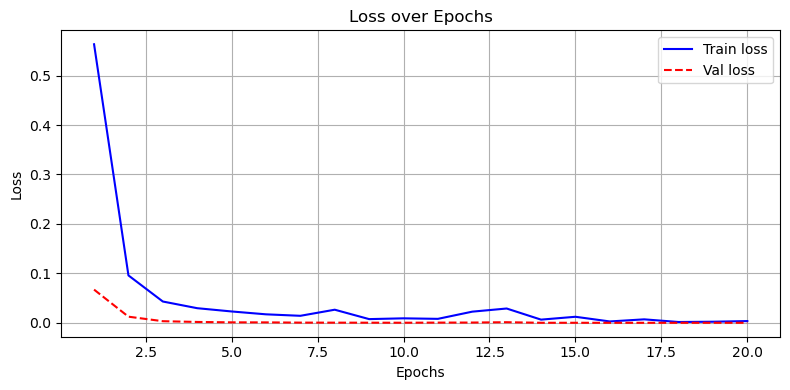

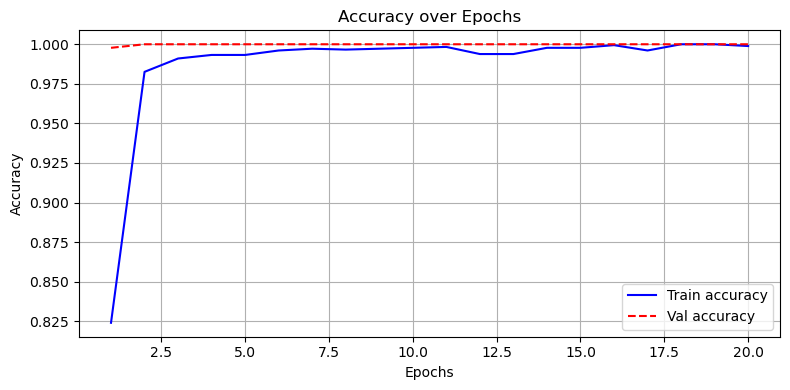

In [42]:
plot_training_history(snapshot_history_time_contra, metrics=['loss', 'accuracy'])

In [43]:
X_sequences = [data_contra_training["rest"], data_contra_training["motor"], data_contra_training["story_math"], data_contra_training["wm"]]
y_true = [0, 1, 2, 3]  # true labels corresponding to above

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


y_pred = [predict_full_sequence(snapshot_model_time_contra, seq, method = 'time') for seq in X_sequences]
print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=label_map.keys()))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("Snapshot validation accuracy:", snapshot_model_time_contra.evaluate(X_val, y_val)[1])
print("Sequence aggregated accuracy:", accuracy_score(y_true, y_pred))

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

        rest       1.00      1.00      1.00         1
       motor       1.00      1.00      1.00         1
  story_math       1.00      1.00      1.00         1
          wm       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


Confusion Matrix:
 [[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 1.4744e-05 
Snapshot validation accuracy: 1.0
Sequence aggregated accuracy: 1.0


### Space aggregation

In [49]:
# Prepare snapshot-level dataset
X_rest = extract_snapshots(data_contra_training["rest"], method='space')
X_motor = extract_snapshots(data_contra_training["motor"], method='space')
X_story = extract_snapshots(data_contra_training["story_math"], method='space')
X_wm = extract_snapshots(data_contra_training["wm"], method='space')

y_rest = np.full((X_rest.shape[0],), label_map['rest'])
y_motor = np.full((X_motor.shape[0],), label_map['motor'])
y_story = np.full((X_story.shape[0],), label_map['story_math'])
y_wm = np.full((X_wm.shape[0],), label_map['wm'])

X_all = np.concatenate([X_rest, X_motor, X_story, X_wm])
y_all = np.concatenate([y_rest, y_motor, y_story, y_wm])


# shuffle??
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)

In [50]:
snapshot_model_space_contra = build_ffnn(input_shape=(X_train.shape[1],))

snapshot_model_space_contra.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
snapshot_history_space_contra = snapshot_model_space_contra.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    verbose=1
)

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2694 - loss: 1.3843 - val_accuracy: 0.3888 - val_loss: 1.3519
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3358 - loss: 1.3504 - val_accuracy: 0.4404 - val_loss: 1.3370
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3539 - loss: 1.3357 - val_accuracy: 0.4674 - val_loss: 1.3141
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3906 - loss: 1.3177 - val_accuracy: 0.4404 - val_loss: 1.2985
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3800 - loss: 1.3061 - val_accuracy: 0.4809 - val_loss: 1.2779
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4071 - loss: 1.2866 - val_accuracy: 0.5034 - val_loss: 1.2663
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4384 - loss: 1.2809 - val_accuracy: 0.4944 - val_loss: 1.2426
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4197 - loss: 1.2781 - val_accuracy: 0.

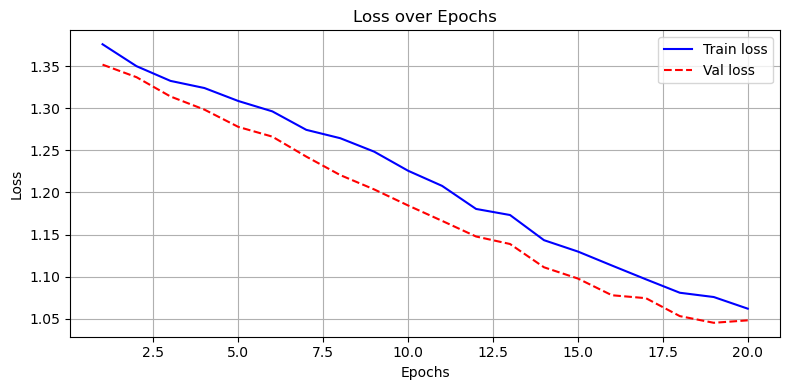

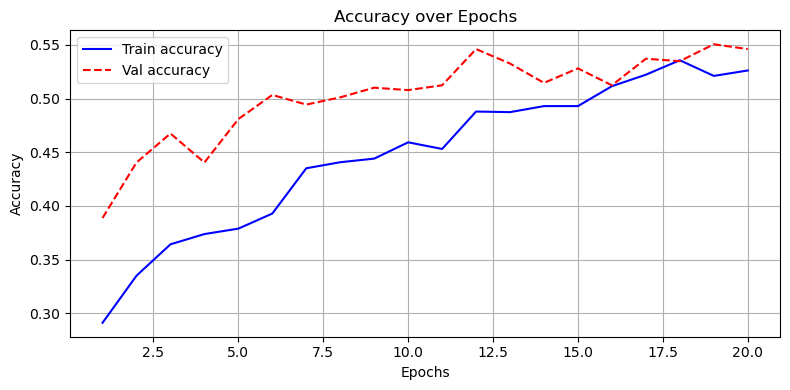

In [51]:
plot_training_history(snapshot_history_space_contra, metrics=['loss', 'accuracy'])

In [52]:
X_sequences = [data_contra_training["rest"], data_contra_training["motor"], data_contra_training["story_math"], data_contra_training["wm"]]
y_true = [0, 1, 2, 3]  # true labels corresponding to above

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


y_pred = [predict_full_sequence(snapshot_model_space_contra, seq, method="space") for seq in X_sequences]
print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=label_map.keys()))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("Snapshot validation accuracy:", snapshot_model_space_contra.evaluate(X_val, y_val)[1])
print("Sequence aggregated accuracy:", accuracy_score(y_true, y_pred))

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

        rest       1.00      1.00      1.00         1
       motor       1.00      1.00      1.00         1
  story_math       1.00      1.00      1.00         1
          wm       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


Confusion Matrix:
 [[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5434 - loss: 1.0460 
Snapshot validation accuracy: 0.5460674166679382
Sequence aggregated accuracy: 1.0


## Testing Contra FFNN

### Prepare data (apply normalization from training set, downsampling)

In [25]:
testdata1 = [
    apply_norm_ds_test(data, params=params)
    for data, params in zip(test_datasets1, norm_params_contra)
]

testdata2 = [
    apply_norm_ds_test(data, params=params)
    for data, params in zip(test_datasets2, norm_params_contra)
]

testdata3 = [
    apply_norm_ds_test(data, params=params)
    for data, params in zip(test_datasets3, norm_params_contra)
]

testdata4 = [
    apply_norm_ds_test(data, params=params)
    for data, params in zip(test_datasets4, norm_params_contra)
]

In [ ]:
reordered_data_dict_contra_test = {}
sensor_order_dict_contra_test = {}
cluster_labels_dict_contra_test = {}

# Reorder all datasets individually
for data1, data2, data3, data4, name in zip(testdata1, testdata2, testdata3, testdata4, task_names):
    reordered1 = data1[sensor_order_contra, :]
    reordered2 = data2[sensor_order_contra, :]
    reordered3 = data3[sensor_order_contra, :]
    reordered4 = data4[sensor_order_contra, :]

    reordered_data_dict_contra_test[f"reordered_data_{name}_testp1"] = reordered1
    reordered_data_dict_contra_test[f"reordered_data_{name}_testp2"] = reordered2
    reordered_data_dict_contra_test[f"reordered_data_{name}_testp3"] = reordered3
    reordered_data_dict_contra_test[f"reordered_data_{name}_testp4"] = reordered4
    sensor_order_dict_contra_test[f"sensor_order_{name}"] = sensor_order_contra
    cluster_labels_dict_contra_test[f"cluster_labels_{name}"] = cluster_labels

In [57]:
conditions = ["rest", "motor", "story_math", "wm"]
test_parts = {
    "test1": ["testp1"],
    "test2": ["testp2"],
    "test3": ["testp3", "testp4"]
}

test_data_combined = {}

for test_key, parts in test_parts.items():
    test_data_combined[test_key] = {}
    for condition in conditions:
        data_list = [
            reordered_data_dict_contra_test[f"reordered_data_{condition}_{part}"]
            for part in parts
        ]
        combined = np.concatenate(data_list, axis=1) if len(data_list) > 1 else data_list[0]
        test_data_combined[test_key][condition] = combined


### Test Evaluation: Time & Space aggregation

In [66]:
snapshot_results = {}
sequence_results = {}

model_map = {
    "time": snapshot_model_time_contra,
    "space": snapshot_model_space_contra,
}

for method in ["time", "space"]:
    model = model_map[method]
    snapshot_results[method] = {}
    sequence_results[method] = {}

    for test_name in ["test1", "test2", "test3"]:
        X_all = []
        y_all = []
        X_sequences = []
        y_true = []

        for condition, label in label_map.items():
            # Get data for this condition and test set
            data = test_data_combined[test_name][condition]

            # Snapshot-level prep
            X = extract_snapshots(data, method=method)
            y = np.full((X.shape[0],), label)

            X_all.append(X)
            y_all.append(y)

            # Sequence-level prep
            X_sequences.append(data)
            y_true.append(label)

        # Concatenate snapshot-level inputs
        X_all = np.concatenate(X_all)
        y_all = np.concatenate(y_all)

        # Snapshot-level evaluation
        snapshot_acc = model.evaluate(X_all, y_all, verbose=0)[1]
        snapshot_results[method][test_name] = snapshot_acc

        # Sequence-level predictions
        y_pred = [predict_full_sequence(model, seq, method=method) for seq in X_sequences]
        sequence_acc = accuracy_score(y_true, y_pred)
        sequence_results[method][test_name] = {
            "accuracy": sequence_acc,
            "report": classification_report(y_true, y_pred, target_names=label_map.keys(), output_dict=False, zero_division=0),
            "confusion": confusion_matrix(y_true, y_pred)
        }

        # Optional: print results
        print(f"\n=== {test_name.upper()} ({method.upper()}) ===")
        print("Sequence Accuracy:", sequence_acc)
        print("Snapshot Accuracy:", snapshot_acc)
        print("Classification Report:\n", classification_report(y_true, y_pred, target_names=label_map.keys(), zero_division=0))
        print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

=== TEST1 (TIME) ===
Sequence Accuracy: 0.5
Snapshot Accuracy: 0.528777003288269
Classification Report:
               precision    recall  f1-score   support

        rest       1.00      1.00      1.00         1
       motor       0.50      1.00      0.67         1
  story_math       0.00      0.00      0.00         1
          wm       0.00      0.00      0.00         1

    accuracy                           0.50         4
   macro avg       0.38      0.50      0.42         4
weighted avg       0.38      0.50      0.42         4

Confusion Matrix:
 [[1 0 0 0]
 [0 1 0 0]
 [0 0 0 1]
 [0 1 0 0]]
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

=== TEST2 (TIME) ===
Sequence Accuracy: 0.75
Snapshot Accuracy: 0.6492805480957031
Classif

# CNN - GRU

## Create training/validation sets for models

### Subchunk prediction


In [12]:
def make_sequences_with_ids(
    data_list,
    labels_list,
    time_per_snapshot=32, 
    sequence_length=10, 
    overlap=0.3  
):
    """
    Creates subchunk sequences for a list of MEG sequences with labels.
    
    Returns:
        X: np.array of shape (num_subchunks, sequence_length, sensors, time_per_snapshot)
        y: np.array of shape (num_subchunks,) — label for each subchunk
        ids: np.array of shape (num_subchunks,) — sequence ID for grouping later
    """
    X = []
    y = []
    ids = []
    seq_counter = 0
    
    for data, label in zip(data_list, labels_list):
        # data shape: (sensors, total_time)
        sensors, total_time = data.shape
        step = int(time_per_snapshot * sequence_length * (1 - overlap))
        step = max(1, step)

        for start in range(0, total_time - time_per_snapshot * sequence_length + 1, step):
            chunk = np.zeros((sequence_length, sensors, time_per_snapshot))
            for j in range(sequence_length):
                snap_start = start + j * time_per_snapshot
                snap_end = snap_start + time_per_snapshot
                chunk[j] = data[:, snap_start:snap_end]
            X.append(chunk)
            y.append(label)
            ids.append(seq_counter)  # group ID for later aggregation

        seq_counter += 1

    return np.array(X), np.array(y), np.array(ids)

## Intra

### Intra training

### Intra Testing

## Contra

In [13]:
label_map = {
    "rest": 0,
    "motor": 1,
    "story_math": 2,
    "wm": 3
}

data_list = []
labels_list = []

for condition in ['rest', 'motor', 'story_math', 'wm']:
    data_p1 = reordered_data_dict_contra[f'reordered_data_{condition}_p1']
    data_p2 = reordered_data_dict_contra[f'reordered_data_{condition}_p2']

    label = label_map[condition]

    # Append data and matching labels
    data_list.extend([data_p1, data_p2])
    labels_list.extend([label, label])

print(f"Data count: {len(data_list)}")
print(f"Labels count: {len(labels_list)}")
print(f"Shape example: {data_list[0].shape if data_list else 'No data'}")


X_all, y_all, ids_all = make_sequences_with_ids(
    data_list=data_list,
    labels_list=labels_list,
    time_per_snapshot=32,
    sequence_length=6
)

X_train, X_val, y_train, y_val, ids_train, ids_val = train_test_split(
    X_all, y_all, ids_all, test_size=0.2, random_state=42, stratify=y_all
)


Data count: 8
Labels count: 8
Shape example: (248, 8906)


In [69]:
print(X_train.shape)
print(y_train.shape)

(422, 6, 248, 32)
(422,)


## Gridsearch - Contra

In [ ]:
from collections import defaultdict, Counter

# gridserach params
cnn_filters = [16, 32, 64]
kernel_sizes = [3, 5]
gru_units = [32, 64, 96, 128]
dense_sizes = [64, 128]
dropout_rates = [0.2, 0.3, 0.4]
learning_rates = [1e-3, 5e-4, 1e-4]
bidirectional_opts = [True, False]
batch_sizes = [8, 16]
epochs = [40, 50]


param_grid = list(itertools.product(
    cnn_filters, kernel_sizes, gru_units, dense_sizes,
    dropout_rates, learning_rates, bidirectional_opts,
    batch_sizes, epochs
))

n_trials = 30
random.seed(42)
sampled_configs = random.sample(param_grid, n_trials)

results = []

# function for majority vote calculation
def majority_vote(preds, ids):
    grouped = defaultdict(list)
    for p, i in zip(preds, ids):
        grouped[i].append(p)
    return {i: Counter(grouped[i]).most_common(1)[0][0] for i in grouped}

# train loop
for cnn_f, ksize, gru_u, dense_s, drop_r, lr, bi, batch_s, epoch_n in sampled_configs:
    print(f"\nTesting config: CNN={cnn_f}, KSize={ksize}, GRU={gru_u}, Dense={dense_s}, Dropout={drop_r}, LR={lr}, BiGRU={bi}, Batch={batch_s}, Epochs={epoch_n}")

    def build_cnn(input_shape, cnn_f, ksize, drop_r):
        inputs = layers.Input(shape=input_shape)  # shape: (sensors, time_per_snapshot)
        x = layers.Conv1D(cnn_f, kernel_size=ksize, activation='relu')(inputs)  # spatial filtering
        x = layers.MaxPooling1D(pool_size=2)(x)
        x = layers.Conv1D(cnn_f * 2, kernel_size=3, activation='relu')(x)
        x = layers.GlobalAveragePooling1D()(x)  # shape: (features,)
        x = layers.Dropout(drop_r)(x)
        return models.Model(inputs, x)


    def build_model(snapshot_shape, sequence_length, num_classes=4):
        cnn_encoder = build_cnn(snapshot_shape)
        inputs = layers.Input(shape=(sequence_length,) + snapshot_shape)
        x = layers.TimeDistributed(cnn_encoder)(inputs)
        if bi:
            x = layers.Bidirectional(layers.GRU(gru_u, return_sequences=True))(x)
            x = layers.Bidirectional(layers.GRU(gru_u, return_sequences=True))(x)
            x = layers.Bidirectional(layers.GRU(gru_u, return_sequences=False))(x)
        else:
            x = layers.GRU(gru_u, return_sequences=True)(x)
            x = layers.GRU(gru_u, return_sequences=True)(x)
            x = layers.GRU(gru_u, return_sequences=False)(x)
        x = layers.Dropout(drop_r)(x)
        x = layers.Dense(dense_s, activation='relu')(x)
        x = layers.Dropout(drop_r)(x)
        outputs = layers.Dense(num_classes, activation='softmax')(x)
        return models.Model(inputs, outputs)

    model = build_model(snapshot_shape=(X_all.shape[2], X_all.shape[3]), sequence_length=X_all.shape[1])
    model.compile(optimizer=Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epoch_n, batch_size=batch_s, verbose=0)
    history_data = history.history

    # subchunk-level accuracy
    best_val_acc = max(history_data['val_accuracy'])
    best_val_loss = min(history_data['val_loss'])

    # subchunk-level predictions
    subchunk_preds = np.argmax(model.predict(X_val, batch_size=batch_s), axis=1)

    # aggregated sequence-level predictions
    aggregated_preds = majority_vote(subchunk_preds, ids_val)
    true_labels = {i: y_val[np.where(ids_val == i)[0][0]] for i in aggregated_preds}
    aggregated_acc = np.mean([aggregated_preds[i] == true_labels[i] for i in aggregated_preds])

    results.append({
        'val_accuracy': best_val_acc,
        'val_loss': best_val_loss,
        'agg_accuracy': aggregated_acc,
        'params': {
            'cnn_filters': cnn_f, 'kernel_size': ksize, 'gru_units': gru_u,
            'dense_size': dense_s, 'dropout': drop_r, 'learning_rate': lr,
            'bidirectional': bi, 'batch_size': batch_s, 'epochs': epoch_n
        },
        'history': history_data
    })

# --- Sort by both accuracy and loss ---
results.sort(key=lambda x: (-x['agg_accuracy'], x['val_loss']))

# --- Top 5 ---
print("\nTop 5 Configurations (by aggregated accuracy and loss):")
for r in results[:5]:
    print(f"Subchunk Val Acc: {r['val_accuracy']:.4f}, Seq Acc: {r['agg_accuracy']:.4f}, Val Loss: {r['val_loss']:.4f}, Params: {r['params']}")



Testing config: CNN=64, KSize=3, GRU=96, Dense=64, Dropout=0.3, LR=0.001, BiGRU=True, Batch=16, Epochs=50


In [ ]:
results.sort(key=lambda x: x['val_accuracy'], reverse=True)

# Get the best result
best_result = results[0]
best_history = best_result['history']

# Print best config
print("Best Configuration:")
for k, v in best_result['params'].items():
    print(f"  {k}: {v}")

# Plotting training and validation accuracy/loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(best_history['accuracy'], label='Train Acc')
plt.plot(best_history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(best_history['loss'], label='Train Loss')
plt.plot(best_history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [54]:
best_params ={'cnn_filters': 64, 'kernel_size': 3, 'gru_units': 96, 'dense_size': 64, 'dropout': 0.3, 'learning_rate': 0.001, 'bidirectional': True, 'batch_size': 16, 'epochs': 30}


def build_cnn(input_shape, cnn_f, ksize, drop_r):
    inputs = layers.Input(shape=input_shape)  # shape: (sensors, time_per_snapshot)
    x = layers.Conv1D(cnn_f, kernel_size=ksize, activation='relu')(inputs)  # spatial filtering
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(cnn_f * 2, kernel_size=3, activation='relu')(x)
    x = layers.GlobalAveragePooling1D()(x)  # shape: (features,)
    x = layers.Dropout(drop_r)(x)
    return models.Model(inputs, x)

def build_model(snapshot_shape, sequence_length, cnn_f, ksize, gru_u, dense_s, drop_r, bi, num_classes=4):
    cnn_encoder = build_cnn(snapshot_shape, cnn_f, ksize, drop_r)
    inputs = layers.Input(shape=(sequence_length,) + snapshot_shape)
    x = layers.TimeDistributed(cnn_encoder)(inputs)
    if bi:
        x = layers.Bidirectional(layers.GRU(gru_u, return_sequences=True))(x)
        x = layers.Bidirectional(layers.GRU(gru_u, return_sequences=True))(x)
        x = layers.Bidirectional(layers.GRU(gru_u, return_sequences=False))(x)
    else:
        x = layers.GRU(gru_u, return_sequences=True)(x)
        x = layers.GRU(gru_u, return_sequences=True)(x)
        x = layers.GRU(gru_u, return_sequences=False)(x)
    x = layers.Dropout(drop_r)(x)
    x = layers.Dense(dense_s, activation='relu')(x)
    x = layers.Dropout(drop_r)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)


best_model = build_model(snapshot_shape=(X_all.shape[2], X_all.shape[3]),
 sequence_length = X_all.shape[1], 
 cnn_f = best_params['cnn_filters'], 
 ksize = best_params['kernel_size'], 
 gru_u = best_params['gru_units'],
 dense_s = best_params['dense_size'],
 drop_r = best_params['dropout'],
 bi = best_params['bidirectional'])

best_model.compile(optimizer=Adam(learning_rate=best_params['learning_rate']), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

best_history = best_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=best_params['epochs'], batch_size=best_params['batch_size'], verbose=0)

In [49]:
best_model.save("1D_model.keras")  # or "best_model.keras"


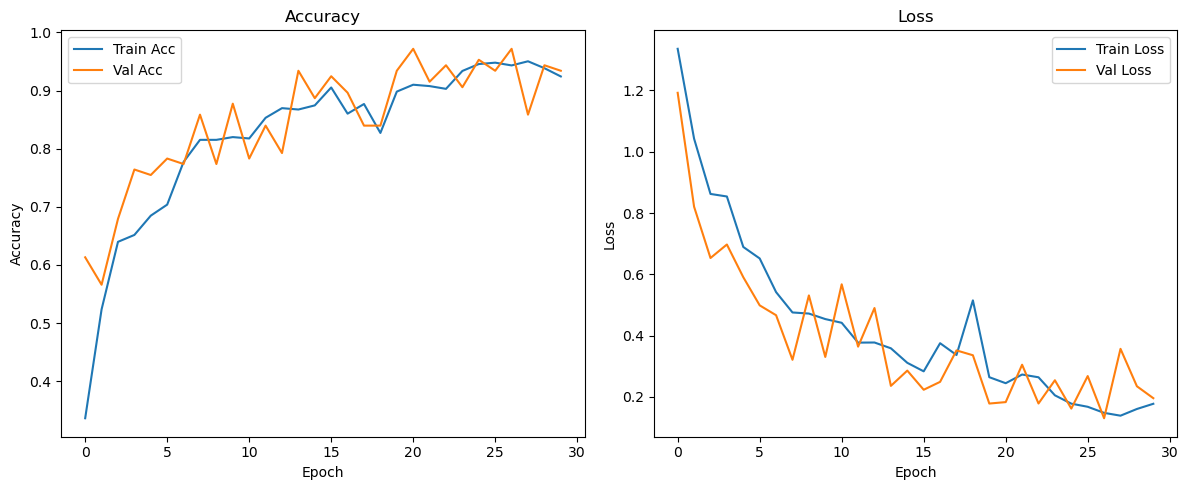

In [55]:
best_history_data = best_history.history


### PLOTS
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(best_history_data['accuracy'], label='Train Acc')
plt.plot(best_history_data['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(best_history_data['loss'], label='Train Loss')
plt.plot(best_history_data['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [56]:
def evaluate_sequences_with_aggregation(model, X_val, y_val, ids_val):
    """
    Evaluate by aggregating predictions from sequences that belong to the same original data
    """
    unique_ids = np.unique(ids_val)
    predictions = []
    true_labels = []
    
    for data_id in unique_ids:
        # get all sequences from the same dataset
        mask = ids_val == data_id
        sequences_from_data = X_val[mask]
        labels_from_data = y_val[mask]
        true_label = labels_from_data[0]
        
        # predictions for these sequences
        sequence_probs = model.predict(sequences_from_data) 
        
        # mean aggregation
        pred_mean = int(np.argmax(np.mean(sequence_probs, axis=0)))
        
        # majority vote aggregation
        sequence_preds = np.argmax(sequence_probs, axis=1)
        pred_vote = int(stat_mode(sequence_preds))
        
        predictions.append({
            'id': data_id,
            'true_label': true_label,
            'pred_mean': pred_mean,
            'pred_vote': pred_vote
        })
        
        true_labels.append(true_label)
    
    return predictions, true_labels

predictions, true_labels = evaluate_sequences_with_aggregation(best_model, X_val, y_val, ids_val)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [57]:
pred_mean_list = [p['pred_mean'] for p in predictions]

print(f"Aggregated accuracy (mean): {accuracy_score(true_labels, pred_mean_list):.4f}")
print("\nClassification Report (Mean Aggregation):")
print(classification_report(true_labels, pred_mean_list, 
                          target_names=['rest', 'motor', 'story_math', 'wm']))

Aggregated accuracy (mean): 1.0000

Classification Report (Mean Aggregation):
              precision    recall  f1-score   support

        rest       1.00      1.00      1.00         2
       motor       1.00      1.00      1.00         2
  story_math       1.00      1.00      1.00         2
          wm       1.00      1.00      1.00         2

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



In [58]:
pred_vote_list = [p['pred_vote'] for p in predictions]

print(f"Aggregated accuracy (vote): {accuracy_score(true_labels, pred_vote_list):.4f}")
print("\nClassification Report (Vote Aggregation):")
print(classification_report(true_labels, pred_vote_list, 
                          target_names=['rest', 'motor', 'story_math', 'wm']))

Aggregated accuracy (vote): 1.0000

Classification Report (Vote Aggregation):
              precision    recall  f1-score   support

        rest       1.00      1.00      1.00         2
       motor       1.00      1.00      1.00         2
  story_math       1.00      1.00      1.00         2
          wm       1.00      1.00      1.00         2

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



In [59]:
# Extract predicted labels from test_predictions (already aggregated by ID)
pred_mean_list = [p['pred_mean'] for p in predictions]
pred_vote_list = [p['pred_vote'] for p in predictions]

# Unique predicted labels
print("Unique predicted classes (mean aggregation):", np.unique(pred_mean_list))
print("Unique predicted classes (vote aggregation):", np.unique(pred_vote_list))

true_labels = [p['true_label'] for p in predictions]
print("True classes in test set:", np.unique(true_labels))

Unique predicted classes (mean aggregation): [0 1 2 3]
Unique predicted classes (vote aggregation): [0 1 2 3]
True classes in test set: [0 1 2 3]


## Contra Testing

In [ ]:
label_map = {
    "rest": 0,
    "motor": 1,
    "story_math": 2,
    "wm": 3
}

def load_test_data(conditions, parts_per_condition):
    data_list, label_list = [], []
    for cond in conditions:
        label = label_map[cond]
        for part_key in parts_per_condition[cond]:
            data = reordered_data_dict_contra_test[part_key]
            data_list.append(data)
            label_list.append(label)
    return data_list, label_list

conditions = ['rest', 'motor', 'story_math', 'wm']
time_per_snapshot = 32
sequence_length = 6

#Test 1: p1
parts_test1 = {cond: [f'reordered_data_{cond}_testp1'] for cond in conditions}
test_data_1, test_labels_1 = load_test_data(conditions, parts_test1)

X_test_1, y_test_1, ids_test_1 = make_sequences_with_ids(
    data_list=test_data_1,
    labels_list=test_labels_1,
    time_per_snapshot=time_per_snapshot,
    sequence_length=sequence_length
)

# --- Test 2: p2 only ---
parts_test2 = {cond: [f'reordered_data_{cond}_testp2'] for cond in conditions}
test_data_2, test_labels_2 = load_test_data(conditions, parts_test2)

X_test_2, y_test_2, ids_test_2 = make_sequences_with_ids(
    data_list=test_data_2,
    labels_list=test_labels_2,
    time_per_snapshot=time_per_snapshot,
    sequence_length=sequence_length
)

# Test 3: p3 and p4 combined
test_data_3 = []
test_labels_3 = []

for cond in conditions:
    # Load both participants' data for this condition
    data_p3 = reordered_data_dict_contra_test[f'reordered_data_{cond}_testp3']
    data_p4 = reordered_data_dict_contra_test[f'reordered_data_{cond}_testp4']
    
    # Merge their trials into a single array
    combined_data = np.concatenate([data_p3, data_p4], axis=0)

    # Append to test data and assign the condition label
    test_data_3.append(combined_data)
    test_labels_3.append(label_map[cond])

# Now pass the combined sequences to the sequence maker
X_test_3, y_test_3, ids_test_3 = make_sequences_with_ids(
    data_list=test_data_3,
    labels_list=test_labels_3,
    time_per_snapshot=time_per_snapshot,
    sequence_length=sequence_length
)

# Optional check
print(f"Test3 data count: {len(test_data_3)}")
print(f"Test3 labels count: {len(test_labels_3)}")
print(f"Example shape: {test_data_3[0].shape if test_data_3 else 'No data'}")



Test3 data count: 4
Test3 labels count: 4
Example shape: (496, 2227)


### Test 1

In [60]:
test_predictions, test_true_labels = evaluate_sequences_with_aggregation(best_model, X_test_1, y_test_1, ids_test_1)

test_pred_mean_list = [p['pred_mean'] for p in test_predictions]
test_pred_vote_list = [p['pred_vote'] for p in test_predictions]

print(f"Aggregated accuracy on test set (mean): {accuracy_score(test_true_labels, test_pred_mean_list):.4f}")
print("\nClassification Report (Mean Aggregation) - Test Set:")
print(classification_report(test_true_labels, test_pred_mean_list, target_names=['rest', 'motor', 'story_math', 'wm'], zero_division=0))

print(f"Aggregated accuracy on test set (vote): {accuracy_score(test_true_labels, test_pred_vote_list):.4f}")
print("\nClassification Report (Vote Aggregation) - Test Set:")
print(classification_report(test_true_labels, test_pred_vote_list, target_names=['rest', 'motor', 'story_math', 'wm'], zero_division=0))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Aggregated accuracy on test set (mean): 0.5000

Classification Report (Mean Aggregation) - Test Set:
              precision    recall  f1-score   support

        rest       0.50      1.00      0.67         1
       motor       0.00      0.00      0.00         1
  story_math       1.00      1.00      1.00         1
          wm       0.00      0.00      0.00         1

    accuracy                           0.50         4
   macro avg       0.38      0.50      0.42         4
weighted avg       0.38      0.50      0.42         4

Aggregated accuracy on test set (vote): 0.5000

Classification Report (Vote Aggregation) - Test Set:
              precision    recall  f1-score   support

        rest       0.50      1.00      0.67         1
       motor       0.00      0.00      0.00         1
  story_math       1.00      1.00      1.00     

In [61]:
# Extract predicted labels from test_predictions (already aggregated by ID)
pred_mean_list = [p['pred_mean'] for p in test_predictions]
pred_vote_list = [p['pred_vote'] for p in test_predictions]

# Unique predicted labels
print("Unique predicted classes (mean aggregation):", np.unique(pred_mean_list))
print("Unique predicted classes (vote aggregation):", np.unique(pred_vote_list))

true_labels = [p['true_label'] for p in test_predictions]
print("True classes in test set:", np.unique(true_labels))


Unique predicted classes (mean aggregation): [0 1 2]
Unique predicted classes (vote aggregation): [0 1 2]
True classes in test set: [0 1 2 3]


### Test 2

In [62]:
test_predictions, test_true_labels = evaluate_sequences_with_aggregation(best_model, X_test_2, y_test_2, ids_test_2)

test_pred_mean_list = [p['pred_mean'] for p in test_predictions]
test_pred_vote_list = [p['pred_vote'] for p in test_predictions]

print(f"Aggregated accuracy on test set (mean): {accuracy_score(test_true_labels, test_pred_mean_list):.4f}")
print("\nClassification Report (Mean Aggregation) - Test Set:")
print(classification_report(test_true_labels, test_pred_mean_list, target_names=['rest', 'motor', 'story_math', 'wm'], zero_division=0))

print(f"Aggregated accuracy on test set (vote): {accuracy_score(test_true_labels, test_pred_vote_list):.4f}")
print("\nClassification Report (Vote Aggregation) - Test Set:")
print(classification_report(test_true_labels, test_pred_vote_list, target_names=['rest', 'motor', 'story_math', 'wm'], zero_division=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Aggregated accuracy on test set (mean): 0.2500

Classification Report (Mean Aggregation) - Test Set:
              precision    recall  f1-score   support

        rest       0.33      1.00      0.50         1
       motor       0.00      0.00      0.00         1
  story_math       0.00      0.00      0.00         1
          wm       0.00      0.00      0.00         1

    accuracy                           0.25         4
   macro avg       0.08      0.25      0.12         4
weighted avg       0.08      0.25      0.12         4

Aggregated accuracy on test set (vote): 0.2500

Classification Report (Vote Aggregation) - Test Set:
              precision    recall  f1-score   support

        rest       0.33      1.00      0.50         1
       motor       0.00      0.00      0.00         1
  story_math       0.00      0.00      0.00     

In [63]:
# Extract predicted labels from test_predictions (already aggregated by ID)
pred_mean_list = [p['pred_mean'] for p in test_predictions]
pred_vote_list = [p['pred_vote'] for p in test_predictions]

# Unique predicted labels
print("Unique predicted classes (mean aggregation):", np.unique(pred_mean_list))
print("Unique predicted classes (vote aggregation):", np.unique(pred_vote_list))

true_labels = [p['true_label'] for p in test_predictions]
print("True classes in test set:", np.unique(true_labels))


Unique predicted classes (mean aggregation): [0 1]
Unique predicted classes (vote aggregation): [0 1]
True classes in test set: [0 1 2 3]


### Test 3

In [64]:
test_predictions, test_true_labels = evaluate_sequences_with_aggregation(best_model, X_test_3, y_test_3, ids_test_3)

test_pred_mean_list = [p['pred_mean'] for p in test_predictions]
test_pred_vote_list = [p['pred_vote'] for p in test_predictions]

print(f"Aggregated accuracy on test set (mean): {accuracy_score(test_true_labels, test_pred_mean_list):.4f}")
print("\nClassification Report (Mean Aggregation) - Test Set:")
print(classification_report(test_true_labels, test_pred_mean_list, target_names=['rest', 'motor', 'story_math', 'wm'], zero_division=0))

print(f"Aggregated accuracy on test set (vote): {accuracy_score(test_true_labels, test_pred_vote_list):.4f}")
print("\nClassification Report (Vote Aggregation) - Test Set:")
print(classification_report(test_true_labels, test_pred_vote_list, target_names=['rest', 'motor', 'story_math', 'wm'], zero_division=0))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Aggregated accuracy on test set (mean): 0.2500

Classification Report (Mean Aggregation) - Test Set:
              precision    recall  f1-score   support

        rest       0.33      1.00      0.50         1
       motor       0.00      0.00      0.00         1
  story_math       0.00      0.00      0.00         1
          wm       0.00      0.00      0.00         1

    accuracy                           0.25         4
   macro avg       0.08      0.25      0.12         4
weighted avg       0.08      0.25      0.12         4

Aggregated accuracy on test set (vote): 0.2500

Classification Report (Vote Aggregation) - Test Set:
              precision    recall  f1-score   support

        rest       0.33      1.00      0.50         1
       motor       0.00      0.00      0.00         1
  story_math       0.00      0.00      0.00       

In [65]:
# Extract predicted labels from test_predictions (already aggregated by ID)
pred_mean_list = [p['pred_mean'] for p in test_predictions]
pred_vote_list = [p['pred_vote'] for p in test_predictions]

# Unique predicted labels
print("Unique predicted classes (mean aggregation):", np.unique(pred_mean_list))
print("Unique predicted classes (vote aggregation):", np.unique(pred_vote_list))

true_labels = [p['true_label'] for p in test_predictions]
print("True classes in test set:", np.unique(true_labels))


Unique predicted classes (mean aggregation): [0 1]
Unique predicted classes (vote aggregation): [0 1]
True classes in test set: [0 1 2 3]
